# ANSWER KEY · Mini-Project 2 — MediCare Outpatient Visits: End-to-End Data Analysis
**Python for Full Stack Data Science with AI & Generative AI · Naresh IT**
*Lead Trainer: Ajit Byru · 3 × 90-minute sessions after Module 15*

**The business problem.** MediCare's hospital administrator has one year of outpatient visit records (`clinic_visits_2025.csv`, ~2,400 visits) and four questions she cannot answer from the billing screen: *Where are patients waiting longest? Which departments actually earn what? Is the clinic getting busier? And what should we change in 2026?*

You are the analyst. **Deliverable:** this notebook, cleaned and complete; a one-paragraph recommendation; a 5-slide summary; a 2-minute pitch.

**Rules:** no `sklearn`, no models — insight, not prediction. Every cleaning decision is written down in the Data-Quality Log. Every question ends in a chart.

| Session | Focus | Sections |
|---|---|---|
| 1 | Load · profile · clean | 1–2 |
| 2 | Five guided questions | 3 |
| 3 | Your own question · recommendation · pitch | 4–6 |

---
## Session 1 — Section 1: Load and profile

Before cleaning anything, *look*. `shape`, `head`, `info`, `describe`, `isna`, `duplicated`, `value_counts` — the profiling checklist from Module 14. Write down every problem you find **before** fixing any of them.

### 1.1 Load
Read the CSV and print its shape and first rows.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv("clinic_visits_2025.csv")
print(raw.shape)
raw.head()

(2423, 13)


,visit_id,patient_id,visit_date,department,doctor,age,gender,city,wait_minutes,consult_minutes,fee,payment_mode,follow_up
0,V101246,P1873,24/11/2025,Pediatrics,Dr. Das,1,F,Warangal,28,5,560.0,UPI,No
1,V101350,P1692,2025-04-28,Dermatology,Dr. Menon,54,M,Hyderabad,9,29,850.0,Insurance,No
2,V102168,P1159,2025-01-31,General Medicine,Dr. Bose,53,M,Hyderabad,21,20,430.0,UPI,No
3,V101745,P1195,23-Jan-2025,Dermatology,Dr. Menon,79,M,Secunderabad,9,24,900.0,UPI,Yes
4,V101334,P1709,2025-08-25,Orthopedics,Dr. Nair,40,M,Warangal,16,20,940.0,Insurance,Yes


### 1.2 `info()` — which columns are the wrong type?
🔮 **PREDICT:** `visit_date` should be a datetime. Will it be?

In [ ]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2423 entries, 0 to 2422
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   visit_id         2423 non-null   str    
 1   patient_id       2423 non-null   str    
 2   visit_date       2423 non-null   str    
 3   department       2423 non-null   str    
 4   doctor           2423 non-null   str    
 5   age              2423 non-null   int64  
 6   gender           2423 non-null   str    
 7   city             2423 non-null   str    
 8   wait_minutes     2423 non-null   int64  
 9   consult_minutes  2423 non-null   int64  
 10  fee              2303 non-null   float64
 11  payment_mode     2423 non-null   str    
 12  follow_up        2423 non-null   str    
dtypes: float64(1), int64(3), str(9)
memory usage: 246.2 KB


> `visit_date` is `str` — three date formats mixed. `fee` has 120 nulls in the raw file (118 unique after dedup).

### 1.3 `describe()` — anything impossible?
Look at `min` and `max` of every numeric column. A hospital dataset has physical limits.

In [ ]:
raw.describe()

,age,wait_minutes,consult_minutes,fee
count,2423.000000,2423.000000,2423.000000,2303.000000
mean,45.039208,28.637639,17.881965,1076.126791
std,24.484135,11.908123,6.252076,3697.973219
min,0.000000,-37.000000,5.000000,430.000000
25%,27.000000,21.000000,13.000000,560.000000
50%,45.000000,28.000000,18.000000,730.000000
75%,64.000000,37.000000,22.500000,1025.000000
max,412.000000,64.000000,35.000000,50000.000000


> `age` max 412, `wait_minutes` min negative. Both impossible. `fee` max 50,000 — suspicious but not impossible.

### 1.4 Missing values and duplicates

In [ ]:
print("Missing values per column:")
print(raw.isna().sum())
print("\nExact duplicate rows:", raw.duplicated().sum())

Missing values per column:
visit_id             0
patient_id           0
visit_date           0
department           0
doctor               0
age                  0
gender               0
city                 0
wait_minutes         0
consult_minutes      0
fee                120
payment_mode         0
follow_up            0
dtype: int64

Exact duplicate rows: 23


### 1.5 Category hygiene
`value_counts()` on `department`. How many departments does MediCare *actually* have?

In [ ]:
print(raw["department"].value_counts())

department
General Medicine      784
Cardiology            375
Orthopedics           370
Dermatology           311
Pediatrics            302
ENT                   221
general medicine        8
 GENERAL MEDICINE       8
cardiology              8
 DERMATOLOGY            6
ent                     6
orthopedics             5
 ORTHOPEDICS            4
 ENT                    4
 CARDIOLOGY             4
 PEDIATRICS             4
dermatology             3
Name: count, dtype: int64


> Six real departments, seventeen spellings. Casing and whitespace — `str.strip().str.title()` territory.

### 1.6 Peek at the dates
Sample a few raw `visit_date` strings. How many different formats can you see?

In [ ]:
print(raw["visit_date"].sample(8, random_state=1).tolist())

['21/06/2025', '2025-04-02', '2025-11-11', '2025-11-06', '14/11/2025', '2025-12-25', '2025-10-02', '2025-08-14']


### 📝 Data-Quality Log — MODEL ANSWER
Record every problem found in 1.1–1.6. Add the fix and reasoning as you clean in Section 2.

| # | Problem found | Rows affected | Fix applied | Why this fix (not another) |
|---|---|---|---|---|
| 1 | | | | |
| 2 | | | | |
| 3 | | | | |
| 4 | | | | |
| 5 | | | | |
| 6 | | | | |
| 7 | | | | |

**Model answer:**

| # | Problem | Rows | Fix | Why |
|---|---|---|---|---|
| 1 | Exact duplicate rows | 23 | `drop_duplicates()` | Same visit_id repeated — a double export, no information lost |
| 2 | Department casing/whitespace | 60 | `strip().title()` + `Ent→ENT` | Same category, different spelling; `title()` breaks acronyms so one manual map |
| 3 | Three date formats; `dayfirst` swaps ISO dates | 596 corrupted by naive parse | Per-format `to_datetime` with `errors="coerce"` | Validated with the Sunday rule: 0 Sundays after fix |
| 4 | Impossible ages (0, 199, 412) | 3 | Reject rows | True age unrecoverable; 3 of 2,400 is negligible |
| 5 | Negative wait minutes | 5 | `abs()` | Sign error at entry; magnitude plausible |
| 6 | Fee > IQR fence (₹50,000) | 13 | **Keep** + `is_procedure` flag | All identical value, all Cardiology/Ortho → procedures, not typos |
| 7 | Missing fee | 118 | Per-department median | Overall median (₹700) would under-price Cardiology by ~45% |

---
## Section 2: Clean

Work on a **copy** (`df = raw.drop_duplicates().copy()`) so `raw` stays untouched for comparison. Order matters: duplicates first (so counts are honest), then text, dates, ranges, outliers, and finally imputation.

### 2.1 Duplicates
Drop exact duplicate rows. Print before / after / removed.

In [ ]:
df = raw.drop_duplicates().copy()
print("Before:", len(raw), " After:", len(df), " Removed:", len(raw) - len(df))

Before: 2423  After: 2400  Removed: 23


### 2.2 Department names
Strip whitespace and standardise case. Then check the result — did the standardisation break anything?

In [ ]:
df["department"] = df["department"].str.strip().str.title()
print(df["department"].value_counts())

department
General Medicine    792
Cardiology          384
Orthopedics         375
Dermatology         318
Pediatrics          304
Ent                 227
Name: count, dtype: int64


> **[TRAP]** `title()` turned `ENT` into `Ent`. Acronyms need a manual map — a small thing that shows whether a student *looked at the output*.

In [ ]:
# .title() turned the acronym ENT into "Ent" -- fix explicitly
df["department"] = df["department"].replace({"Ent": "ENT"})
print(sorted(df["department"].unique()))

['Cardiology', 'Dermatology', 'ENT', 'General Medicine', 'Orthopedics', 'Pediatrics']


### 2.3 Dates — the trap
Three formats live in one column. The tempting one-liner is `pd.to_datetime(..., format="mixed", dayfirst=True)`. Run it and look at the weekday distribution.

🔮 **PREDICT:** MediCare is closed on Sundays. How many Sunday visits should there be?

In [ ]:
# [TRAP] The obvious one-liner. Looks fine...
parsed = pd.to_datetime(df["visit_date"], format="mixed", dayfirst=True)
print(parsed.dtype)
print("Range:", parsed.min().date(), "to", parsed.max().date())
print(parsed.dt.day_name().value_counts())

datetime64[us]
Range: 2025-01-01 to 2025-12-31
visit_date
Monday       459
Friday       410
Tuesday      408
Wednesday    380
Thursday     355
Saturday     305
Sunday        83
Name: count, dtype: int64


> **[TRAP]** 83 Sunday visits at a clinic closed on Sundays. Range looks fine, dtype looks fine — the bug is invisible unless you know a business rule. This is the most important moment in the project.

### 2.4 Investigate
Compare the ISO-formatted strings with what the parser produced.

In [11]:
# The clinic is CLOSED on Sundays. 83 Sunday visits means the parser is wrong somewhere.
iso_rows = df["visit_date"].str.match(r"\d{4}-\d{2}-\d{2}$")
iso_text = df.loc[iso_rows, "visit_date"]
swapped = parsed[iso_rows].dt.strftime("%Y-%m-%d") != iso_text
print("ISO dates silently day/month-swapped:", swapped.sum(), "of", iso_rows.sum())
print(pd.DataFrame({"text": iso_text[swapped], "parsed": parsed[iso_rows][swapped].dt.date}).head(4))

ISO dates silently day/month-swapped: 596 of 1683
          text      parsed
6   2025-11-12  2025-12-11
10  2025-02-12  2025-12-02
12  2025-03-04  2025-04-03
13  2025-04-09  2025-09-04


> `dayfirst=True` is applied to ISO strings too: `2025-11-12` becomes 11-Dec. Only dates with day ≤ 12 flip, so 596 of 1,683 ISO rows silently moved. **Lesson: never let a parser guess when you know the formats.**

### 2.5 Fix — parse each format explicitly
Write a function that tries each format in turn with `errors="coerce"` and fills gaps. Verify: zero unparsed, zero Sundays.

In [12]:
def parse_dates(s):
    out = pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")          # ISO first
    out = out.fillna(pd.to_datetime(s, format="%d/%m/%Y", errors="coerce"))  # then dd/mm/yyyy
    out = out.fillna(pd.to_datetime(s, format="%d-%b-%Y", errors="coerce"))  # then dd-Mon-yyyy
    return out

df["visit_date"] = parse_dates(df["visit_date"])
print("Unparsed:", df["visit_date"].isna().sum())
print("Range:", df["visit_date"].min().date(), "to", df["visit_date"].max().date())
print(df["visit_date"].dt.day_name().value_counts())

Unparsed: 0
Range: 2025-01-01 to 2025-12-31
visit_date
Monday       495
Friday       422
Wednesday    408
Tuesday      397
Thursday     376
Saturday     302
Name: count, dtype: int64


### 2.6 Impossible ages
Find ages ≤ 0 or > 110. Decide: repair or reject? (There is no way to recover a true age — reject, and record the visit_ids.)

In [13]:
bad_age = df[(df["age"] <= 0) | (df["age"] > 110)]
print(bad_age[["visit_id", "department", "age"]])
df = df[(df["age"] > 0) & (df["age"] <= 110)]
print("Rows after age filter:", len(df))

     visit_id        department  age
1629  V101228  General Medicine    0
2032  V102161        Cardiology  412
2251  V102242  General Medicine  199
Rows after age filter: 2397


### 2.7 Negative wait times
A negative wait is a sign error at data entry, not a real value. Decide: repair (`abs`) or reject? Justify in the log.

In [14]:
neg = df[df["wait_minutes"] < 0]
print("Negative wait rows:", len(neg))
df.loc[df["wait_minutes"] < 0, "wait_minutes"] = df.loc[df["wait_minutes"] < 0, "wait_minutes"].abs()
print("Min wait now:", df["wait_minutes"].min())

Negative wait rows: 5
Min wait now: 3


### 2.8 Fee outliers — the judgement call
Apply the 1.5 × IQR fence from Module 15. Then **look at what it flags** before doing anything.

In [15]:
q1, q3 = df["fee"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
flagged = df[df["fee"] > upper]
print(f"Q1={q1}, Q3={q3}, IQR={iqr}, upper fence={upper}")
print("Rows above fence:", len(flagged))
print(flagged["department"].value_counts())
print(flagged["fee"].unique())

Q1=560.0, Q3=1030.0, IQR=470.0, upper fence=1735.0
Rows above fence: 13
department
Orthopedics    7
Cardiology     6
Name: count, dtype: int64
[50000.]


> **[BEAT]** The fence is right to flag; the analyst is right to keep. Thirteen visits, every one exactly ₹50,000, every one in the two departments that do procedures. Dropping them would erase ₹6.5 lakh of real revenue. Rules find candidates; judgement decides.

### 2.9 Decide
The fence flags them. Are they errors? Look at the values and the departments. Write your decision in the log.

In [16]:
# Decision: KEEP. All flagged fees are exactly 50,000 and all sit in Cardiology / Orthopedics —
# consistent with a procedure, not a typo. We add a flag so analysis can include or exclude them deliberately.
df["is_procedure"] = df["fee"] == 50000
print(df["is_procedure"].sum(), "procedures flagged")

13 procedures flagged


### 2.10 Missing fees
Impute with a median — but *which* median? 🔮 **PREDICT:** What goes wrong if you use the overall median for a Cardiology visit?

In [17]:
print("Missing fees:", df["fee"].isna().sum())
# median fee PER DEPARTMENT (a missing cardiology fee should not get a paediatrics number)
dept_median = df.groupby("department")["fee"].median()
print(dept_median)
df["fee"] = df["fee"].fillna(df["department"].map(dept_median))
print("Missing fees now:", df["fee"].isna().sum())

Missing fees: 118
department
Cardiology          1260.0
Dermatology          850.0
ENT                  740.0
General Medicine     520.0
Orthopedics         1060.0
Pediatrics           630.0
Name: fee, dtype: float64
Missing fees now: 0


> Overall median ≈ ₹700. Per-department median ranges ₹520–₹1,260. Imputation must respect the group — the same idea as `groupby`, applied to filling gaps.

### 2.11 Derived columns and save
Add `weekday` and `month`. Save `clinic_visits_clean.csv`. Print the final shape — this is your acceptance number.

In [18]:
df["weekday"] = df["visit_date"].dt.day_name()
df["month"] = df["visit_date"].dt.month
print("Clean shape:", df.shape)
print("Departments:", df["department"].nunique(), "| Doctors:", df["doctor"].nunique(), "| Cities:", df["city"].nunique())
df.to_csv("clinic_visits_clean.csv", index=False)

Clean shape: (2397, 16)
Departments: 6 | Doctors: 11 | Cities: 5


> **Acceptance numbers:** 2,423 → 2,400 (dedup) → 2,397 (age) rows; 16 columns; 6 departments; 11 doctors; 0 missing fees; 0 Sunday visits; 13 procedures.

---
## Session 2 — Section 3: Five guided questions

Each question ends in a chart with a title, axis labels and a one-sentence reading in the markdown cell below it. **A chart without a sentence is not an answer.**

### Q1. Which department is busiest, and on which weekday?
Two bar charts. Reading: what does Monday mean for staffing?

department
General Medicine    790
Cardiology          383
Orthopedics         375
Dermatology         318
Pediatrics          304
ENT                 227
Name: count, dtype: int64


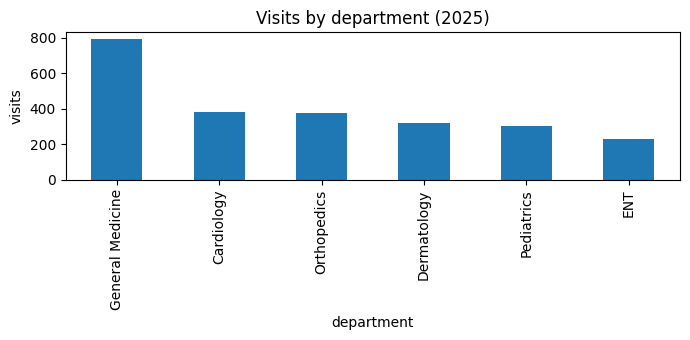

In [19]:
by_dept = df["department"].value_counts()
print(by_dept)
plt.figure(figsize=(7, 3.5))
by_dept.plot(kind="bar")
plt.title("Visits by department (2025)")
plt.ylabel("visits")
plt.tight_layout()
plt.show()

weekday
Monday       495
Tuesday      396
Wednesday    407
Thursday     376
Friday       421
Saturday     302
Sunday         0
Name: count, dtype: int64


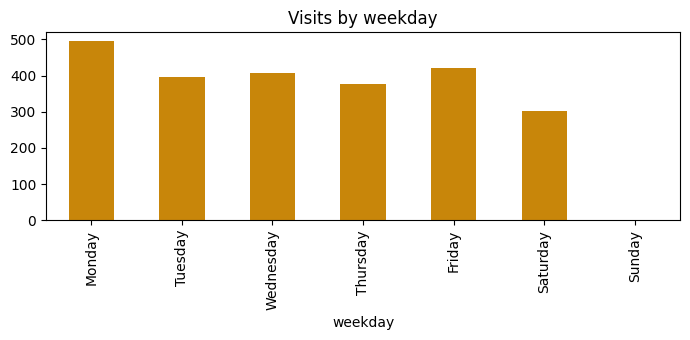

In [20]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_day = df["weekday"].value_counts().reindex(order).fillna(0).astype(int)
print(by_day)
plt.figure(figsize=(7, 3.5))
by_day.plot(kind="bar", color="#C8860A")
plt.title("Visits by weekday")
plt.tight_layout()
plt.show()

> General Medicine carries a third of all visits (790). Monday is ~25% busier than a mid-week day (495 vs ~400). Reading: Monday morning is where a second General Medicine desk pays for itself.

### Q2. Where do patients wait longest?
Group wait time by department: mean, median, std, and the 90th percentile. Box plot. Reading: which department's *worst* days matter most?

                  mean  median  std   p90
department                               
General Medicine  37.8    38.0  8.9  49.0
Cardiology        31.9    32.0  9.0  43.0
Orthopedics       25.9    26.0  8.8  37.0
Pediatrics        22.1    22.5  8.6  32.0
ENT               20.1    19.0  9.0  32.4
Dermatology       18.4    18.0  8.5  29.3


<Figure size 700x350 with 0 Axes>

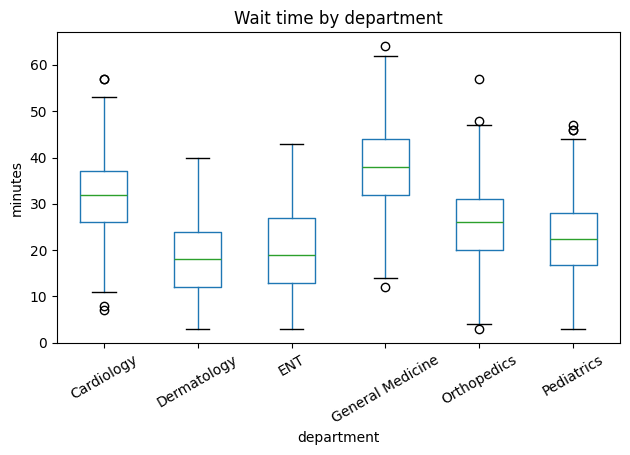

In [21]:
wait_stats = df.groupby("department")["wait_minutes"].agg(mean="mean", median="median", std="std", p90=lambda s: s.quantile(0.9)).round(1)
print(wait_stats.sort_values("mean", ascending=False))
plt.figure(figsize=(7, 3.5))
df.boxplot(column="wait_minutes", by="department", grid=False)
plt.suptitle("")
plt.title("Wait time by department")
plt.ylabel("minutes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

> General Medicine waits longest (mean 37.8, p90 49 min); Dermatology shortest (18.4). Std is ~9 everywhere — the *departments* differ, not the variability. Reading: it is a capacity problem, not a consistency problem.

### Q3. What does each department really earn per visit?
Mean vs median fee by department, with and without procedures. Reading: which number would you put in the annual report, and why?

In [22]:
fee_stats = df.groupby("department")["fee"].agg(mean="mean", median="median", max="max").round(0)
print(fee_stats)
print("\nExcluding procedures:")
print(df[~df["is_procedure"]].groupby("department")["fee"].agg(mean="mean", median="median").round(0))

                    mean  median      max
department                               
Cardiology        2021.0  1260.0  50000.0
Dermatology        847.0   850.0   1000.0
ENT                736.0   740.0    870.0
General Medicine   522.0   520.0    620.0
Orthopedics       1973.0  1060.0  50000.0
Pediatrics         632.0   630.0    750.0

Excluding procedures:
                    mean  median
department                      
Cardiology        1258.0  1260.0
Dermatology        847.0   850.0
ENT                736.0   740.0
General Medicine   522.0   520.0
Orthopedics       1059.0  1060.0
Pediatrics         632.0   630.0


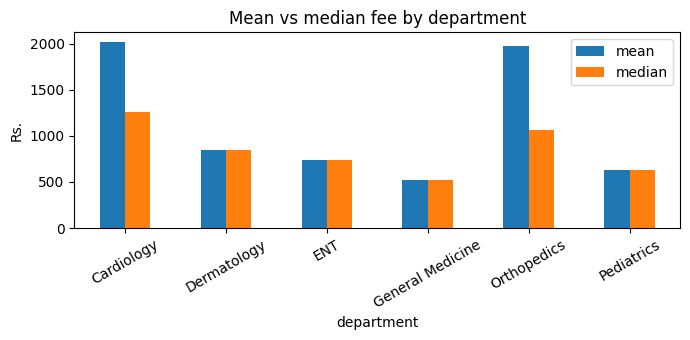

In [23]:
fig, ax = plt.subplots(figsize=(7, 3.5))
fee_stats[["mean", "median"]].plot(kind="bar", ax=ax)
ax.set_title("Mean vs median fee by department")
ax.set_ylabel("Rs.")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

> Cardiology mean ₹2,021 vs median ₹1,260 — the Spice Route lesson at scale. Excluding procedures, mean and median agree within ₹5 everywhere. Reading: report *consultation* fees by median and *procedure* revenue separately.

### Q4. Does patient age relate to consultation length?
Scatter, `r`, `np.polyfit` line. Reading: how much longer per decade of age?

r = 0.767
consult_minutes = 0.21 * age + 8.56
Predicted consult for a 70-year-old: 23.1 min


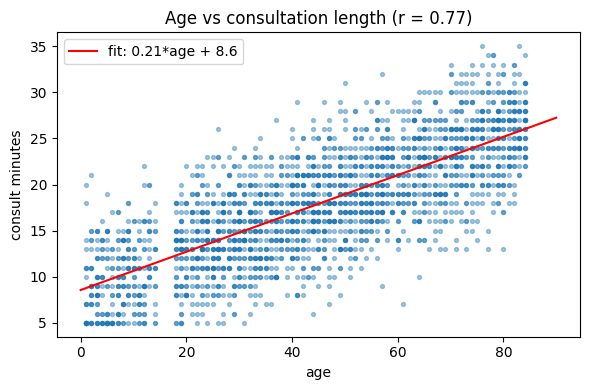

In [24]:
r = np.corrcoef(df["age"], df["consult_minutes"])[0, 1]
m, c = np.polyfit(df["age"], df["consult_minutes"], deg=1)
print(f"r = {r:.3f}")
print(f"consult_minutes = {m:.2f} * age + {c:.2f}")
print("Predicted consult for a 70-year-old:", round(m * 70 + c, 1), "min")
xs = np.linspace(0, 90, 50)
plt.figure(figsize=(6, 4))
plt.scatter(df["age"], df["consult_minutes"], s=8, alpha=0.4)
plt.plot(xs, m * xs + c, color="red", label=f"fit: {m:.2f}*age + {c:.1f}")
plt.xlabel("age")
plt.ylabel("consult minutes")
plt.title(f"Age vs consultation length (r = {r:.2f})")
plt.legend()
plt.tight_layout()
plt.show()

> r = 0.77; slope 0.21 min/year ≈ 2 minutes per decade. A 70-year-old needs ~23 minutes vs ~13 for a 20-year-old. Reading: appointment slots should be age-aware.

### Q5. Is the clinic getting busier? Monthly revenue trend
Line chart, all revenue vs consultations only. Reading: are the spikes growth or single events?

month
1     3.62
2     1.85
3     2.08
4     2.11
5     2.57
6     2.46
7     1.46
8     1.81
9     2.67
10    1.66
11    1.46
12    1.79
Name: fee, dtype: float64


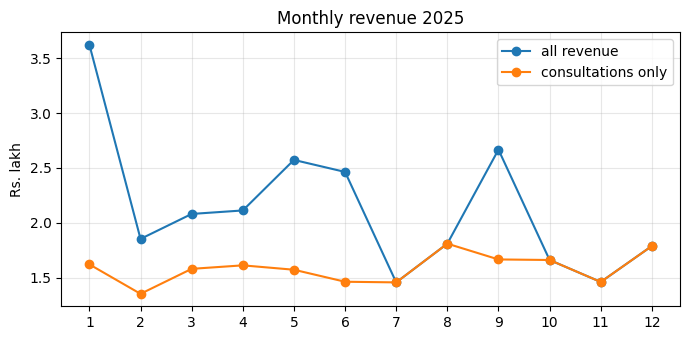

In [25]:
monthly = df.groupby("month")["fee"].sum() / 1e5
monthly_no_proc = df[~df["is_procedure"]].groupby("month")["fee"].sum() / 1e5
print(monthly.round(2))
plt.figure(figsize=(7, 3.5))
plt.plot(monthly.index, monthly.values, marker="o", label="all revenue")
plt.plot(monthly_no_proc.index, monthly_no_proc.values, marker="o", label="consultations only")
plt.xticks(range(1, 13))
plt.ylabel("Rs. lakh")
plt.title("Monthly revenue 2025")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> Consultation revenue is flat (~₹1.6–2.0 lakh/month). The January, May and September spikes are procedures (January alone has four ₹50,000 procedures), not growth. Reading: without the `is_procedure` flag this chart would tell a false story.

---
## Session 3 — Section 4: Your own question

Pick **one** and take it further than the guided questions did — this is your headline finding and your slide 3.

1. **Doctor workload** — is any doctor carrying an unfair share of visits or wait time within their department?
2. **Follow-up compliance** — which departments/ages come back for follow-up, and which don't?
3. **Payment-mode trends** — is UPI displacing cash across the year? Does mode differ by city or age?
4. **City-wise access** — do out-of-city patients wait longer or pay more?
5. **Consultation efficiency** — wait vs consult ratio by department: where does the queue exceed the care?
6. **Revenue concentration** — what share of revenue comes from the top 10% of visits? Top 2 departments?

Requirements: at least one `groupby`, one chart, one statistic you can defend, and a sentence on what you'd need to be sure.

In [26]:
# Example own-question: doctor workload in General Medicine
gm = df[df["department"] == "General Medicine"]
load = gm.groupby("doctor").agg(visits=("visit_id", "count"), avg_wait=("wait_minutes", "mean"), avg_consult=("consult_minutes", "mean")).round(1)
print(load)

            visits  avg_wait  avg_consult
doctor                                   
Dr. Bose       270      38.1         19.0
Dr. Khan       247      37.2         19.2
Dr. Pillai     273      37.9         19.1


> Example for option 1: General Medicine doctors are evenly loaded (~250–270 visits each, identical waits). Workload is not the lever — capacity is.

---
## Section 5: Recommendation

**One paragraph, 120–180 words, written for the administrator (not for your trainer).** Structure: the single most important finding → the number that proves it → what to change in 2026 → one thing you would check with more data.

> **Model paragraph:** MediCare's clearest problem is General Medicine: it handles 33% of visits (790) and has the longest waits — a mean of 38 minutes and a 90th percentile of 49 — while every other department averages under 32. Waits are not erratic (standard deviation ≈ 9 minutes in every department); they are structurally higher, which points to capacity rather than process. Mondays carry ~25% more visits than a mid-week day, so the pressure is concentrated. Recommendation for 2026: add one General Medicine consulting slot on Mondays and Tuesdays, and move to age-aware appointment lengths, since consultation time rises ~2 minutes per decade of patient age (r = 0.77). Report consultation fees by median and procedures separately; the ₹50,000 procedures otherwise inflate Cardiology's apparent average by 60%. With more data I would check whether long waits drive the 65% no-follow-up rate.

---
## Section 6: Presentation

**Five slides** (template in `README.md`): 1 Question · 2 Data & cleaning · 3 Three findings · 4 Recommendation · 5 What I'd do next.
**Two-minute pitch** in class. **README** with the cleaning log summary and the five interview questions answered.

### The cliffhanger
`np.polyfit` fitted consult time from *one* column. The administrator asks: "Can you predict it from age **and** department **and** doctor together?" With what you know today — no. Module 16 — yes.

In [27]:
# The Module 16 hook: one predictor, one line. What if we used age AND department AND doctor?
print("With np.polyfit we can only use ONE column to predict consult_minutes.")
print("Next module: a model that uses all of them at once.")

With np.polyfit we can only use ONE column to predict consult_minutes.
Next module: a model that uses all of them at once.
